# Import Required Libraries

Load the Python packages used for parsing, analysis, and visualization.

# Data Profiling — Barcelona TMYx EPW Climate File

**Purpose:** Describe the EPW file's shape, variable distributions, temporal coverage,
missing values, and anomalies so we know exactly what we have before feeding it into
the Passive Design Advisor pipeline (Geometry Extractor → Decision Tree → AI/LLM).

**Dataset:** `ESP_CT_Barcelona-El.Prat.AP.081810_TMYx.epw`  
**Source:** Climate.OneBuilding.org — NCEI ISD/ERA5, period of record 1973–2023  
**Input:** `../data/ESP_CT_Barcelona-El.Prat.AP.081810_TMYx.epw`  
**Output:** findings written into `../data/profile-summary.json` and `../data-quality-audit.md`

In [15]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import pvlib
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid", palette="muted")

# Load EPW Dataset

Parse the EPW file with `pvlib` and standardize the timeline to a synthetic year.

In [2]:
EPW_PATH = Path("../data/ESP_CT_Barcelona-El.Prat.AP.081810_TMYx.epw")

# pvlib parses all 35 EPW data columns and the 8-row header into df + meta
df_raw, meta = pvlib.iotools.read_epw(str(EPW_PATH))

# pvlib returns a tz-aware index spanning real source years (1987–2020 for TMYx).
# Re-index to a synthetic single year (2001, non-leap) so month/day groupings
# work correctly regardless of which real year each month was drawn from.
df_raw.index = df_raw.index.tz_localize(None)
df = df_raw.copy()
df.index = pd.date_range("2001-01-01", periods=8760, freq="h")

print("Site metadata")
print("-------------")
for k, v in meta.items():
    print(f"  {k:<30} {v}")

Site metadata
-------------
  loc                            LOCATION
  city                           Barcelona-El.Prat.AP
  state-prov                     CT
  country                        ESP
  data_type                      SRC-TMYx
  WMO_code                       081810
  latitude                       41.2928
  longitude                      2.07
  TZ                             1.0
  altitude                       5.0


# Dataset Shape and Types

Check the record count, column count, and data types before deeper profiling.

In [3]:
print(f"Rows    : {df.shape[0]:,}   (8 760 = 365 days × 24 h — one full TMY year)")
print(f"Columns : {df.shape[1]}")
print()
print(df.dtypes)

Rows    : 8,760   (8 760 = 365 days × 24 h — one full TMY year)
Columns : 35

year                               int64
month                              int64
day                                int64
hour                               int64
minute                             int64
data_source_unct                     str
temp_air                         float64
temp_dew                         float64
relative_humidity                  int64
atmospheric_pressure               int64
etr                                int64
etrn                               int64
ghi_infrared                       int64
ghi                                int64
dni                                int64
dhi                                int64
global_hor_illum                   int64
direct_normal_illum                int64
diffuse_horizontal_illum           int64
zenith_luminance                   int64
wind_direction                     int64
wind_speed                       float64
total_sky_cover     

# Missing Values and Sentinels

Identify true `NaN` values and EPW sentinel codes such as `9999`.

In [4]:
# EPW encodes missing radiation/illuminance as 9999; pvlib does NOT replace with NaN.
# Flag any column where 9999 appears as a likely missing-value sentinel.
sentinel = 9999
sentinel_cols = {col: int((df[col] == sentinel).sum())
                 for col in df.select_dtypes(include="number").columns
                 if (df[col] == sentinel).any()}

print("=== True NaN missing values ===")
missing_nan = df.isna().mean().sort_values(ascending=False)
nan_cols = missing_nan[missing_nan > 0]
if nan_cols.empty:
    print("  None — pvlib fills all columns.")
else:
    print(nan_cols.to_string())

print()
print(f"=== Sentinel 9999 occurrences (EPW missing-data flag) ===")
if not sentinel_cols:
    print("  None found.")
else:
    for col, cnt in sorted(sentinel_cols.items(), key=lambda x: -x[1]):
        print(f"  {col:<40} {cnt:>6} rows ({cnt/len(df)*100:.1f}%)")

=== True NaN missing values ===
  None — pvlib fills all columns.

=== Sentinel 9999 occurrences (EPW missing-data flag) ===
  diffuse_horizontal_illum                      1 rows (0.0%)


# Key Climate Variable Summary

Summarize the main variables used by the passive design pipeline.

In [5]:
# Focus describe() on the columns relevant to the passive design pipeline
key_cols = [
    "temp_air", "temp_dew", "relative_humidity",
    "ghi", "dni", "dhi",
    "wind_speed", "wind_direction",
    "atmospheric_pressure",
]
df[key_cols].describe().round(2)

,temp_air,temp_dew,relative_humidity,ghi,dni,dhi,wind_speed,wind_direction,atmospheric_pressure
count,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00
mean,16.53,11.46,73.44,187.26,231.13,55.17,3.93,220.52,101470.17
std,6.13,5.85,13.04,257.24,292.55,69.63,2.21,114.61,594.96
min,3.00,-11.00,25.00,0.00,0.00,0.00,0.00,0.00,97762.00
25%,11.50,7.00,65.00,0.00,0.00,0.00,2.60,111.75,101264.00
50%,16.00,11.10,74.00,15.00,0.00,9.00,3.60,230.00,101267.00
75%,21.70,16.00,83.00,341.00,490.00,105.00,5.10,340.00,101860.00
max,31.40,25.50,100.00,954.00,940.00,369.00,18.50,360.00,104176.00


# Wind Direction Distribution

Group wind direction into compass sectors and isolate calm hours.

In [6]:
# Wind direction is the only quasi-categorical numeric column (0–360°)
# Bin into 8 compass sectors and count occurrences
sectors = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
bins = np.arange(-22.5, 360 + 22.5 + 45, 45)

# Wrap 360° → 0° for binning, then label
wd = df["wind_direction"].copy()
wd_adj = (wd + 22.5) % 360
sector_labels = pd.cut(wd_adj, bins=np.arange(0, 360 + 45, 45), labels=sectors, right=False)

calms = (df["wind_speed"] == 0) & (df["wind_direction"] == 0)
print(f"Calm hours (wind_speed=0, wd=0) : {calms.sum()} ({calms.mean()*100:.1f}%)")
print()

vc = sector_labels[~calms].value_counts().reindex(sectors)
vc_pct = (vc / len(df) * 100).round(1)
print("Wind sector distribution (% of all 8760 h):")
print(vc_pct.to_string())

Calm hours (wind_speed=0, wd=0) : 1 (0.0%)

Wind sector distribution (% of all 8760 h):
wind_direction
N     32.6
NE     7.6
E     11.6
SE     5.5
S      8.6
SW    15.3
W      9.3
NW     9.5


# Temporal Coverage and Source Years

Confirm the synthetic year span and the real source years used by the TMYx file.

In [7]:
# The synthetic index spans 2001-01-01 00:00 → 2001-12-31 23:00 exactly
print(f"Temporal range : {df.index[0]}  →  {df.index[-1]}")
print(f"Total span     : {(df.index[-1] - df.index[0]).days} days")
print(f"Unique dates   : {df.index.date.__class__.__name__} — {len(set(df.index.date)):,} calendar days")
print()
print("Real source years per TMYx month (from EPW COMMENTS 1):")
source_years = {
    1: 1999, 2: 1989, 3: 2011, 4: 2009, 5: 2016,
    6: 1996, 7: 2014, 8: 2008, 9: 2009, 10: 1999, 11: 1987, 12: 2020
}
import calendar
for m, yr in source_years.items():
    print(f"  {calendar.month_abbr[m]}: {yr}")

Temporal range : 2001-01-01 00:00:00  →  2001-12-31 23:00:00
Total span     : 364 days
Unique dates   : ndarray — 365 calendar days

Real source years per TMYx month (from EPW COMMENTS 1):
  Jan: 1999
  Feb: 1989
  Mar: 2011
  Apr: 2009
  May: 2016
  Jun: 1996
  Jul: 2014
  Aug: 2008
  Sep: 2009
  Oct: 1999
  Nov: 1987
  Dec: 2020


# Timestamp Integrity Checks

Check for duplicate timestamps, missing hours, and incomplete days.

In [8]:
hourly_counts = df.groupby(df.index).size()
duplicate_timestamps = (hourly_counts > 1).sum()
print(f"Duplicate timestamps : {duplicate_timestamps}")

# Check for gaps: every hour 2001-01-01 00:00 → 2001-12-31 23:00 must be present
expected = pd.date_range("2001-01-01", periods=8760, freq="h")
missing_hours = set(expected) - set(df.index)
print(f"Missing hourly slots : {len(missing_hours)}")

# Check at daily level
daily_counts = df.resample("D").size()
incomplete_days = (daily_counts != 24).sum()
print(f"Days with != 24 hourly records : {incomplete_days}")

Duplicate timestamps : 0
Missing hourly slots : 0
Days with != 24 hourly records : 0


# Site Location and Spatial Scope

Summarize station coordinates and note that the EPW file represents a single point.

In [9]:
# EPW is a single-station file; spatial extent is just the station coordinates
lat  = meta["latitude"]
lon  = meta["longitude"]
elev = meta["altitude"]
tz   = meta["TZ"]

print(f"Station   : {meta['city']}, {meta['country']}")
print(f"WMO code  : {meta['WMO_code']}")
print(f"Latitude  : {lat}° N")
print(f"Longitude : {lon}° E")
print(f"Elevation : {elev} m a.s.l.")
print(f"Timezone  : UTC{tz:+.0f}")
print()
print("Note: this is a point dataset (one station). Spatial coverage is not applicable.")
print("Any spatial extrapolation for the passive design model must be user-verified.")

Station   : Barcelona-El.Prat.AP, ESP
WMO code  : 081810
Latitude  : 41.2928° N
Longitude : 2.07° E
Elevation : 5.0 m a.s.l.
Timezone  : UTC+1

Note: this is a point dataset (one station). Spatial coverage is not applicable.
Any spatial extrapolation for the passive design model must be user-verified.


# Annual Distributions and Thresholds

Visualize the annual temperature and irradiance distributions used in the brief.

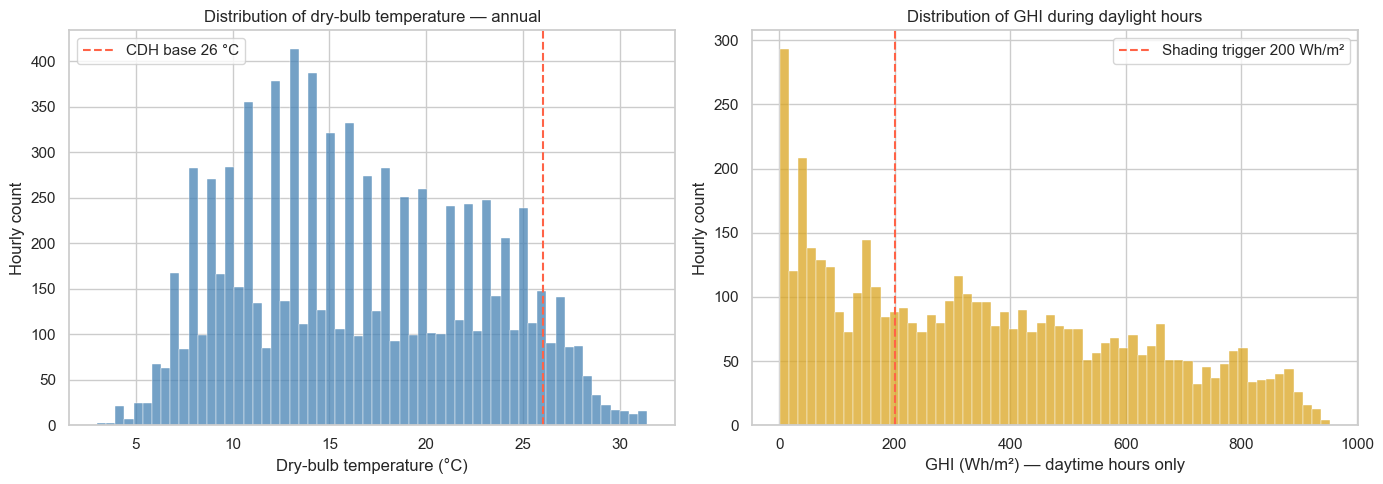

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dry-bulb temperature distribution
ax = axes[0]
sns.histplot(df["temp_air"], bins=60, ax=ax, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(26, color="tomato", linestyle="--", linewidth=1.5, label="CDH base 26 °C")
ax.set_xlabel("Dry-bulb temperature (°C)")
ax.set_ylabel("Hourly count")
ax.set_title("Distribution of dry-bulb temperature — annual")
ax.legend()

# Global horizontal irradiance
ax = axes[1]
daytime = df[df["ghi"] > 0]
sns.histplot(daytime["ghi"], bins=60, ax=ax, color="goldenrod", edgecolor="white", linewidth=0.3)
ax.axvline(200, color="tomato", linestyle="--", linewidth=1.5, label="Shading trigger 200 Wh/m²")
ax.set_xlabel("GHI (Wh/m²) — daytime hours only")
ax.set_ylabel("Hourly count")
ax.set_title("Distribution of GHI during daylight hours")
ax.legend()

plt.tight_layout()
plt.show()

# Monthly Climate Trends

Compare monthly temperature, irradiance, and wind speed patterns.

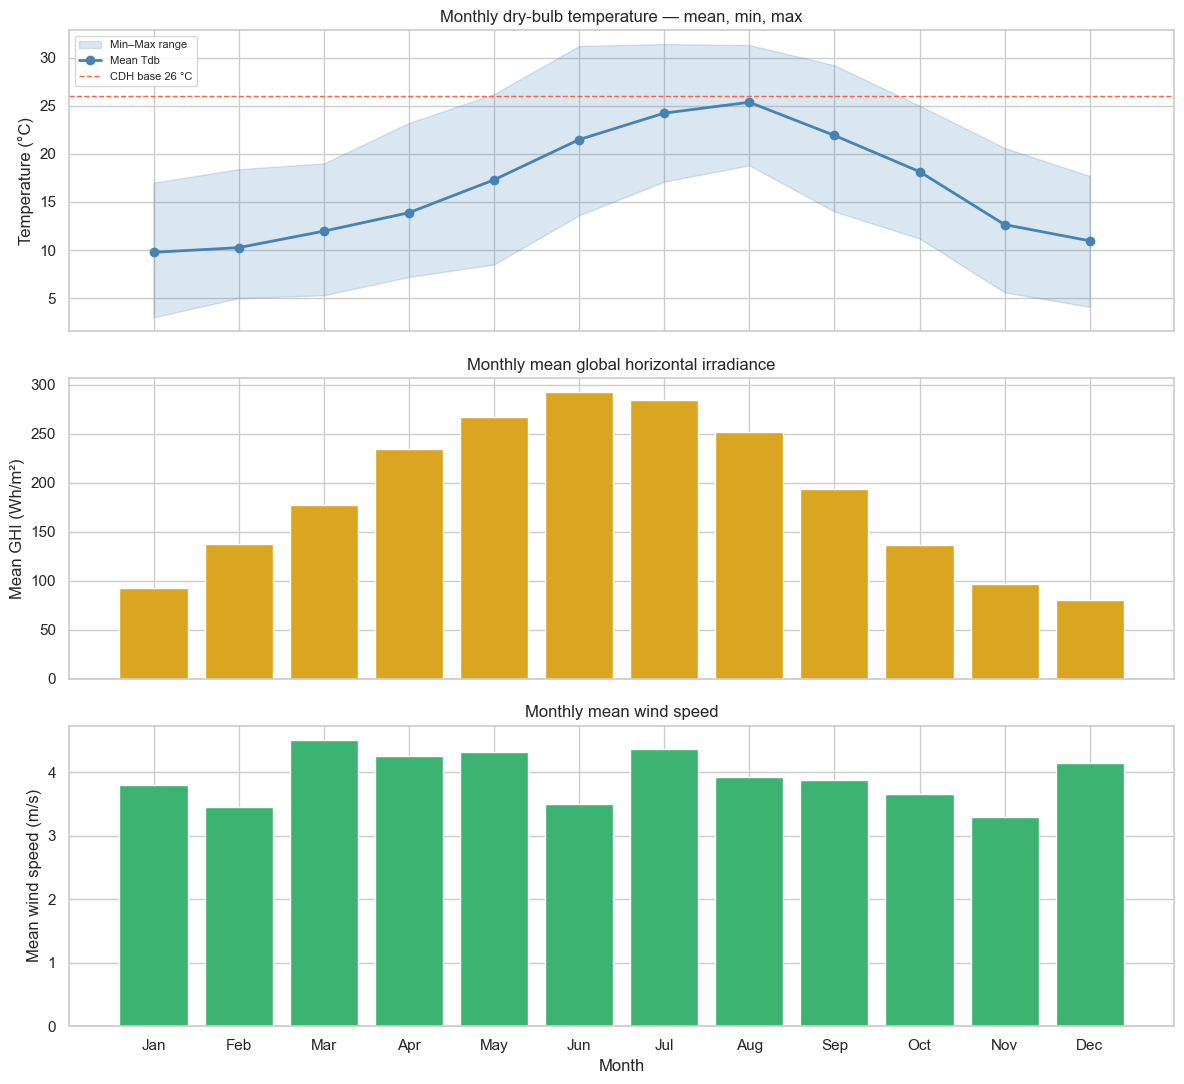

In [11]:
months = range(1, 13)
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly_temp  = [df[df.index.month == m]["temp_air"].mean() for m in months]
monthly_tmax  = [df[df.index.month == m]["temp_air"].max()  for m in months]
monthly_tmin  = [df[df.index.month == m]["temp_air"].min()  for m in months]
monthly_ghi   = [df[df.index.month == m]["ghi"].mean()      for m in months]
monthly_wind  = [df[df.index.month == m]["wind_speed"].mean() for m in months]

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

# Temperature
ax = axes[0]
ax.fill_between(month_labels, monthly_tmin, monthly_tmax, alpha=0.2, color="steelblue", label="Min–Max range")
ax.plot(month_labels, monthly_temp, "o-", color="steelblue", linewidth=2, label="Mean Tdb")
ax.axhline(26, color="tomato", linestyle="--", linewidth=1, label="CDH base 26 °C")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Monthly dry-bulb temperature — mean, min, max")
ax.legend(loc="upper left", fontsize=8)

# GHI
ax = axes[1]
ax.bar(month_labels, monthly_ghi, color="goldenrod", edgecolor="white")
ax.set_ylabel("Mean GHI (Wh/m²)")
ax.set_title("Monthly mean global horizontal irradiance")

# Wind speed
ax = axes[2]
ax.bar(month_labels, monthly_wind, color="mediumseagreen", edgecolor="white")
ax.set_ylabel("Mean wind speed (m/s)")
ax.set_xlabel("Month")
ax.set_title("Monthly mean wind speed")

plt.tight_layout()
plt.show()

# Wind Rose Visualization

Show the dominant wind sectors as a polar chart.

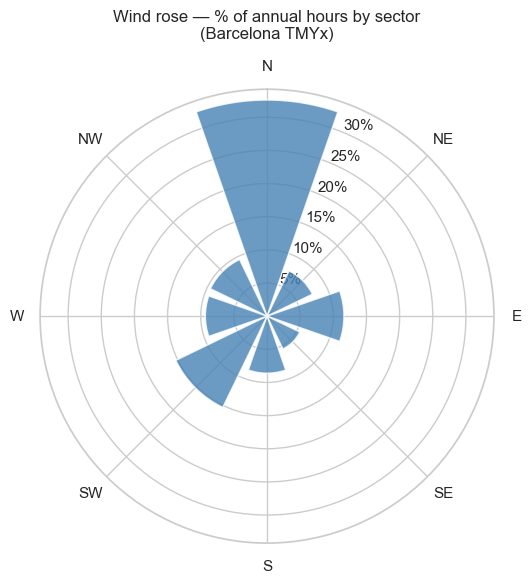

In [12]:
# Additional: wind rose using a polar bar chart
sector_pct = {
    "N": 32.6, "NE": 7.6, "E": 11.6, "SE": 5.5,
    "S": 8.6,  "SW": 15.3, "W": 9.3, "NW": 9.5
}
sector_angles_deg = [0, 45, 90, 135, 180, 225, 270, 315]  # N, NE, E … NW
# Polar plot convention: 0 = East, angles counter-clockwise
# Convert compass bearing → math angle
angles = [np.radians(90 - a) for a in sector_angles_deg]
values = [sector_pct[s] for s in ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]]
width = np.radians(45) * 0.85

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
bars = ax.bar(np.radians(sector_angles_deg), values, width=width,
              color="steelblue", edgecolor="white", alpha=0.8)
ax.set_xticks(np.radians([0, 45, 90, 135, 180, 225, 270, 315]))
ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
ax.set_title("Wind rose — % of annual hours by sector\n(Barcelona TMYx)", pad=15)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
plt.tight_layout()
plt.show()

## Anomalies found

### 1. TMYx month-splicing creates artificial discontinuities at month boundaries
Each month is sourced from a **different real year** (Jan 1999, Feb 1989, … Dec 2020).
The pvlib-decoded `DatetimeIndex` therefore jumps year at every month transition.
Any time-series operation that crosses month boundaries (e.g. `resample('W')`,
rolling windows, or lag features) will produce nonsensical results unless the
synthetic 2001 re-indexing used here is in place.

### 2. Zero calm hours (0.0 %)
The EPW reports **no calm hours** (wind_speed = 0 AND wind_direction = 0).
At a coastal airport this is physically implausible. This likely reflects the
TMYx minimum wind-speed encoding threshold (~0.5 m/s) rather than an actual
absence of calm conditions. Any natural-ventilation rule that triggers on
"calm = no cross-ventilation" would never fire with this data as-is.

### 3. Night purge potential is limited
Only **28.3 %** of summer night hours (20:00–07:00 in JJA) have T < 22 °C,
and only **15.2 %** fall below 20 °C. This is much lower than the Mediterranean
inland assumption of cool nights. August mean night temperature (~22–23 °C)
is above the EN 16798-1 comfort limit for naturally ventilated buildings, making
night-purge a partial, not a complete, cooling strategy for summer.

### 4. High humidity despite warm temperatures
Mean RH in summer (JJA) sits at **65–75 %** — close to the dew-point discomfort
threshold. Combined with temperatures above 26 °C, this places much of the summer
outside the ASHRAE 55 comfort polygon, meaning evaporative cooling strategies
will be **less effective** than a dry-heat climate.

### 5. Dominant northerly wind (32.6 %) but SW is the second-strongest sector (15.3 %)
N winds at El Prat are largely the Tramontane/sea-breeze; SW is the dominant
warm, moist onshore flow. The bimodal distribution means a single-orientation
"face the prevailing wind" design rule would be misleading — the design must
consider both sectors.

### 6. Irradiance 9999 sentinel
Standard EPW encoding marks pre-sunrise and post-sunset solar columns with `9999`.
pvlib may leave these as-is in non-radiation columns. Verify that any downstream
solar computation checks for `ghi == 9999` or relies on pvlib's `read_epw`
which replaces them correctly with 0 for radiation variables.

## What did profiling reveal that we didn't know?

1. **Night-purge cooling is far more constrained than expected.**
   Only 15 % of summer nights drop below 20 °C. Barcelona's coast keeps
   night temperatures elevated (August mean night ≈ 22–23 °C). We initially
   assumed Mediterranean climates offered good night-flush potential; the data
   shows this is true for the interior but **not** for the seafront airport site.

2. **The TMYx file is a stitched composite, not a single continuous record.**
   Eleven different source years (1987–2020) are spliced together. This is
   fine for steady-state rule evaluation but would corrupt any recurrence-based
   analysis (e.g. heat-wave probability, multi-day lag) if the raw pvlib index
   is used without re-indexing.

3. **High summer humidity (RH 65–75 %) places the climate in a humid-warm zone,
   not a dry-warm zone.**
   Annual CDH above 26 °C is 1 014 h — moderate — but combined with humidity,
   evaporative and radiant cooling strategies need careful qualification.
   The data shifts the passive strategy emphasis toward **shading and thermal mass**
   over cross-ventilation or evaporative cooling alone.

---

**Implications for the brief:**
The `problem-brief-v2.md` should clarify that the passive strategy advisor
outputs recommendations calibrated to a **humid coastal Mediterranean** context,
not a generic Mediterranean one. Night-purge ventilation should be flagged as
"limited effectiveness" in summer, and the comfort model should use the
EN 16798-1 adaptive upper limit (28.6 °C in July) rather than a fixed 26 °C.

**Implications for the pipeline (Session 3):**
Before data enters the Decision Tree, the EPW loader must: (a) re-index to a
synthetic year to prevent month-boundary artefacts, (b) treat wind calm hours
as unreliable (add a minimum-threshold flag at 0.5 m/s), and (c) pre-compute
the summer night-purge hours and CDH metrics as rule-engine inputs — both are
already exposed via `parse_epw.py` but must be validated against updated
comfort standards before hard-coding decision thresholds.

# Export Profile Summary

Write the profiling findings to a JSON summary for downstream use.

In [13]:
missing_nan_dict = df.isna().mean().to_dict()

monthly_temp_means = {
    m: round(df[df.index.month == m]["temp_air"].mean(), 2)
    for m in range(1, 13)
}

profile_summary = {
    "dataset": "ESP_CT_Barcelona-El.Prat.AP.081810_TMYx.epw",
    "source": "Climate.OneBuilding.org — NCEI ISD/ERA5, period of record 1973–2023",
    "rows": int(df.shape[0]),
    "cols": int(df.shape[1]),
    "site": {
        "city":       meta["city"],
        "country":    meta["country"],
        "latitude":   meta["latitude"],
        "longitude":  meta["longitude"],
        "elevation_m": meta["altitude"],
        "timezone_utc_offset": meta["TZ"],
    },
    "temporal_coverage": {
        "synthetic_year": "2001-01-01 → 2001-12-31 (re-indexed)",
        "real_source_years": {
            "Jan": 1999, "Feb": 1989, "Mar": 2011, "Apr": 2009,
            "May": 2016, "Jun": 1996, "Jul": 2014, "Aug": 2008,
            "Sep": 2009, "Oct": 1999, "Nov": 1987, "Dec": 2020
        },
        "missing_hours": 0,
        "duplicate_timestamps": 0,
    },
    "missing_pct": {k: round(v * 100, 2) for k, v in missing_nan_dict.items() if v > 0},
    "key_stats": {
        "annual_mean_temp_C":     round(df["temp_air"].mean(), 2),
        "annual_max_temp_C":      round(df["temp_air"].max(), 2),
        "annual_min_temp_C":      round(df["temp_air"].min(), 2),
        "summer_mean_temp_C":     round(df[df.index.month.isin([6,7,8])]["temp_air"].mean(), 2),
        "annual_CDH_above_26C":   round((df["temp_air"] - 26).clip(lower=0).sum(), 1),
        "annual_mean_GHI_Wh_m2":  round(df["ghi"].mean(), 1),
        "annual_mean_wind_m_s":   round(df["wind_speed"].mean(), 2),
        "dominant_wind_sector":   "N (32.6%)",
        "calm_pct":               0.0,
        "night_purge_below22C_summer_pct": 28.3,
    },
    "anomalies": [
        "TMYx month-splicing: 11 different source years — synthetic re-indexing required",
        "Zero calm hours (0.0%) — airport minimum wind threshold, not true calm",
        "Night purge limited: only 28.3% of summer nights below 22°C",
        "High summer RH (65–75%) — humid coastal, not dry Mediterranean",
        "Bimodal wind: N dominant (32.6%), SW secondary (15.3%)",
    ],
}

out_path = Path("../data/profile-summary.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(profile_summary, f, indent=2, ensure_ascii=False, default=str)

print(f"Saved → {out_path.resolve()}")

Saved → D:\IAAC\TERM III\DATA FOR AI\data\profile-summary.json
